In [68]:
import sys
sys.path.append('../')

import warnings
warnings.filterwarnings("ignore")
import os
import seaborn as sns

from utils import *
from tqdm.auto import tqdm
from generate_parameter_sample import PARAMETER_RANGES
from scipy.stats import gaussian_kde, ks_2samp, pearsonr
import numpy as np
import pandas as pd
import pickle

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, classification_report, confusion_matrix, accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay, PartialDependenceDisplay

from experiment import unpack_and_dequantize

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({"font.size" : 15,
                     "figure.dpi" : 100, 
                     "grid.alpha" : 0.3, 
                     "axes.grid": False, 
                     "axes.axisbelow" : True,
                     "figure.figsize":(8,6),
                     "mathtext.fontset":"cm",
                     "xtick.labelsize": 14,
                     "ytick.labelsize": 14,
                     "axes.labelsize": 16, 
                     "legend.fontsize": 13.5})
plt.rc("text", usetex=False)
plt.rc("font", family="serif")

# Heatmap for Dominant Amplitudes

### CPT

In [27]:
directory = "cpt"
with open("../"+directory + "_dominant_frequencies_amplitudes.pickle", "rb") as f:
    freqs = pickle.load(f)
data = []
for idx,f in tqdm(enumerate(os.listdir("../"+directory))):
    with open(os.path.join("../"+directory, f), "rb") as f:
        P = pickle.load(f)["params"]
    elem = ((P["alpha"], P["gamma"], P["lambda"], P["rate"], P["A"], freqs[idx]["amplitudes"]))
    data.append(elem)

0it [00:00, ?it/s]

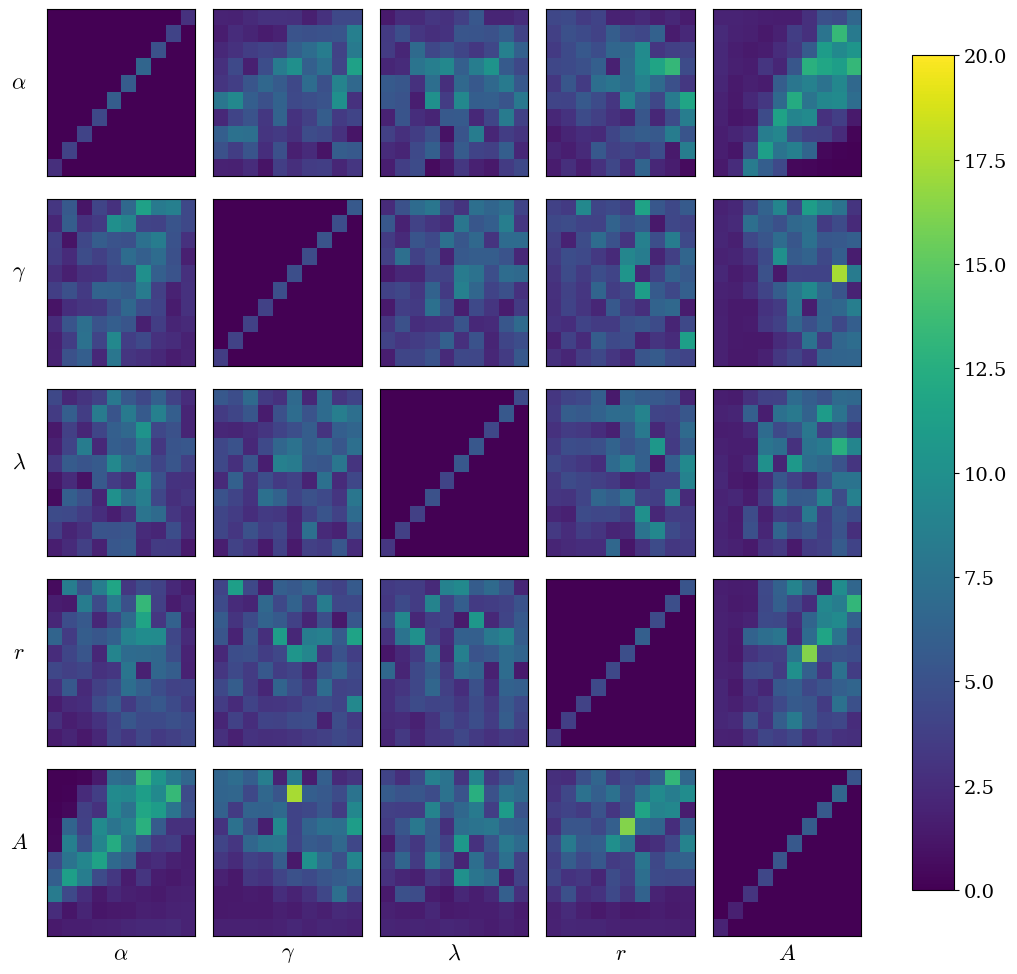

In [29]:
param_names = [r"$\alpha$", r"$\gamma$", r"$\lambda$", r"$r$", r"$A$"]
bounds = list(PARAMETER_RANGES.values())
freq_lists = [d[-1] for d in data]

num_bins = 11

fig, axs = plt.subplots(len(param_names), len(param_names), figsize=(11,10))

for i in range(len(param_names)):
    pi_values = np.array([d[i] for d in data])
    pi_bounds = np.linspace(bounds[i][0], bounds[i][1], num_bins)
    for j in range(len(param_names)):
        pj_values = np.array([d[j] for d in data])
        pj_bounds = np.linspace(bounds[j][0], bounds[j][1], num_bins)
        heatmap = np.zeros((num_bins-1, num_bins-1))
        
        # Iterate over bins
        for a in range(num_bins-1):
            for b in range(num_bins-1):
                # Find indices that fall into this bin
                idxs = np.where(
                    (pi_values >= pi_bounds[a]) & (pi_values < pi_bounds[a+1]) &
                    (pj_values >= pj_bounds[b]) & (pj_values < pj_bounds[b+1])
                )[0]

                if len(idxs) > 0:
                    amplitudes = [freq_lists[k] for k in idxs]
                    if amplitudes:
                        combined = np.concatenate(amplitudes) 
                        combined[np.isnan(combined)] = 0
                        heatmap[a, b] = combined.mean()
                    else:
                        heatmap[a, b] = 0
                else:
                    heatmap[a, b] = 0

        # Threshold mask: 1 if >= 20, else 0
        im = axs[i][j].imshow(heatmap, origin="lower", aspect="auto", vmin=0, vmax=20)
            
        axs[i][j].set_xticks([])
        axs[i][j].set_yticks([])
        if j == 0:
            axs[i][j].set_ylabel(param_names[i], rotation=0, labelpad=20)
        if i == len(param_names)-1:
            axs[i][j].set_xlabel(param_names[j])

        last_im = im

fig.tight_layout()
fig.colorbar(last_im, ax=axs.ravel().tolist(), shrink=0.9)
plt.show()

### PT

In [23]:
directory = "pt"
with open("../"+directory + "_dominant_frequencies_amplitudes.pickle", "rb") as f:
    freqs = pickle.load(f)

data = []
for idx,f in tqdm(enumerate(os.listdir("../"+directory))):
    with open(os.path.join("../"+directory, f), "rb") as f:
        P = pickle.load(f)["params"]
    elem = ((P["alpha"], P["rate"], P["A"], P["lambda"], freqs[idx]["amplitudes"]))
    data.append(elem)

0it [00:00, ?it/s]

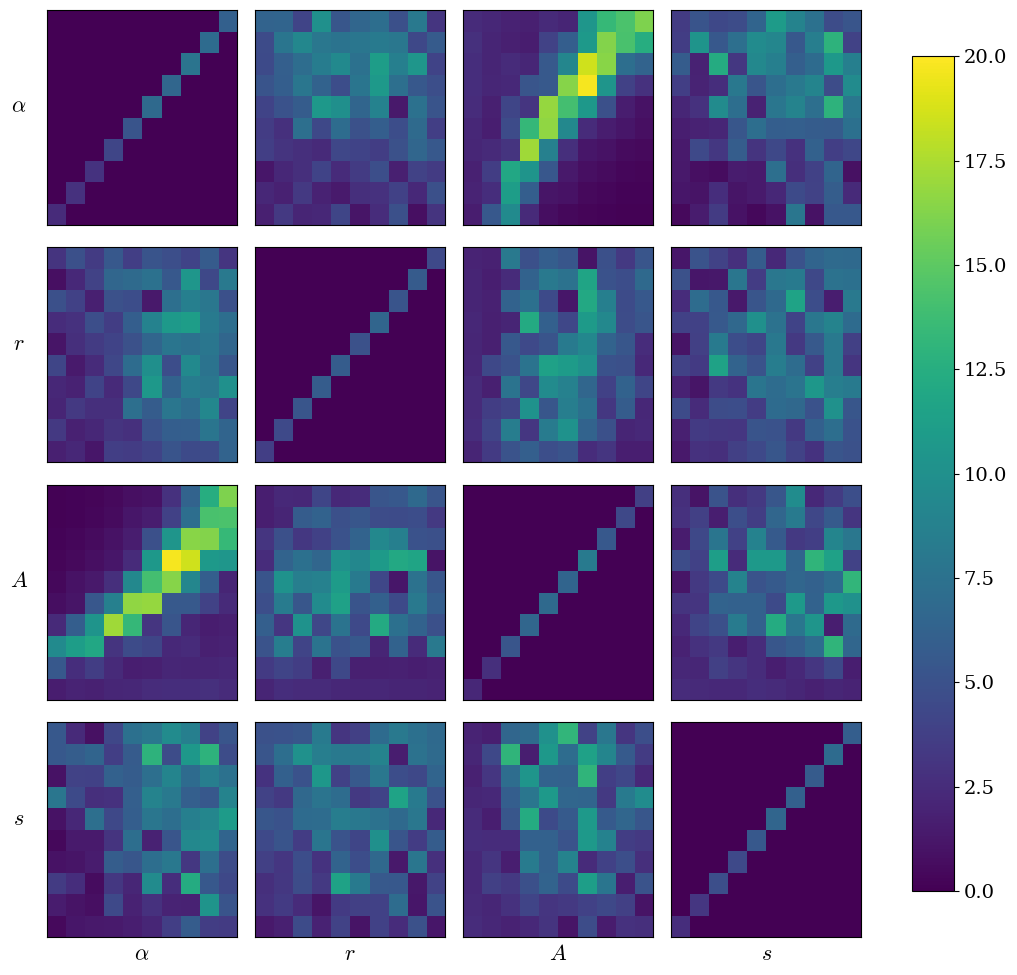

In [26]:
fig, axs = plt.subplots(4, 4, figsize=(11,10))

param_names = [r"$\alpha$", r"$r$", r"$A$", r"$s$"]
bounds = list([PARAMETER_RANGES[k] for k in ["alpha", "rate", "A", "lambda"]])
freq_lists = [d[-1] for d in data]

map_vals = []
for i in range(len(param_names)):
    pi_values = np.array([d[i] for d in data])
    pi_bounds = np.linspace(bounds[i][0], bounds[i][1], 11)
    for j in range(len(param_names)):
        pj_values = np.array([d[j] for d in data])
        pj_bounds = np.linspace(bounds[j][0], bounds[j][1], 11)
        heatmap = np.zeros((10, 10))

        # Iterate over bins
        for a in range(10):
            for b in range(10):
                # Find indices that fall into this bin
                idxs = np.where(
                    (pi_values >= pi_bounds[a]) & (pi_values < pi_bounds[a+1]) &
                    (pj_values >= pj_bounds[b]) & (pj_values < pj_bounds[b+1])
                )[0]

                if len(idxs) > 0:
                    amplitudes = [freq_lists[k] for k in idxs]
                    if amplitudes:
                        combined = np.concatenate(amplitudes) 
                        combined[np.isnan(combined)] = 0
                        heatmap[a, b] = combined.mean()
                    else:
                        heatmap[a,b] = 0
                else:
                    heatmap[a, b] = 0

        im = axs[i][j].imshow(heatmap, origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=20)
        axs[i][j].set_xticks([])
        axs[i][j].set_yticks([])
        if j == 0:
            axs[i][j].set_ylabel(param_names[i], rotation=0, labelpad=20)
        if i == len(param_names)-1:
            axs[i][j].set_xlabel(param_names[j])
        last_im = im

        map_vals.append(heatmap.flatten())

fig.tight_layout()
fig.colorbar(last_im, ax=axs.ravel().tolist(), shrink=0.9)
plt.show()

# KDE of Dominant Amplitudes

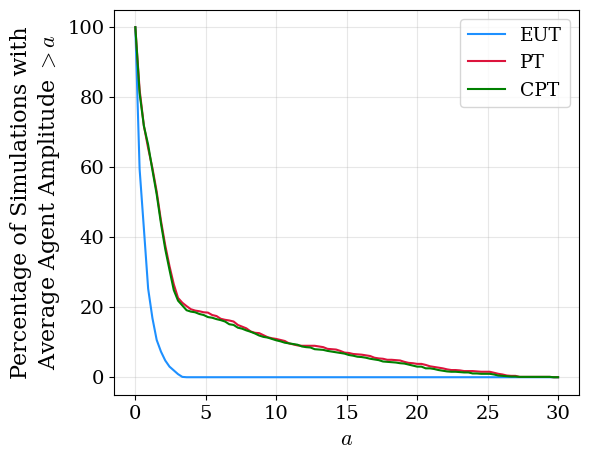

In [20]:
plt.figure(figsize=(6,5))

cutoffs = np.linspace(0, 30, 100)
labels = ["EUT", "PT", "CPT"]
colors = ["dodgerblue", "crimson", "green"]
for i, model in enumerate(["data/eut/eut_95/", "data/pt/pt_95/", "data/cpt/cpt_kt_95/"]):
    with open("../"+model + "dominant_frequencies_amplitudes.pickle", "rb") as f:
        amplitudes = pickle.load(f)
    count = []
    sims = [s["amplitudes"] for s in amplitudes]
    sims = np.concatenate(sims)
    sims = sims[~np.isnan(sims)]
    for mean_dominant_amplitude in cutoffs:
        subset = [x for x in amplitudes if np.mean(x["amplitudes"]) > mean_dominant_amplitude]
        count.append(100 * len(subset)/1024)
    plt.plot(cutoffs, count, label=labels[i], color=colors[i])

plt.legend()
plt.grid()
plt.ylabel("Percentage of Simulations with" + "\n"+ r"Average Agent Amplitude $> a$")
plt.xlabel(r"$a$")
# plt.title(r"$\beta=0.95$")
#plt.savefig("../figures/percent_simulations_amplitude.pdf", bbox_inches="tight")
plt.show()

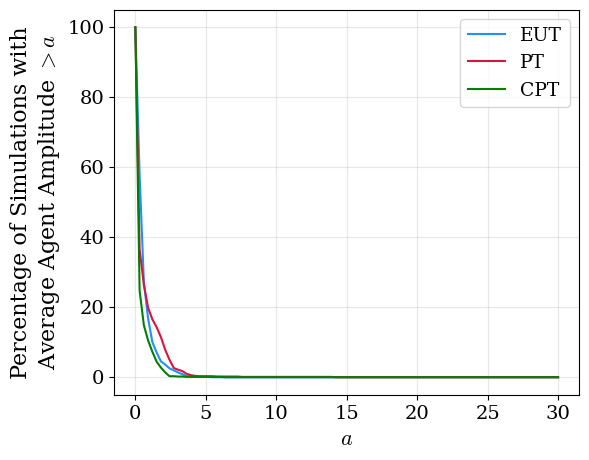

In [69]:
plt.figure(figsize=(6,5))

cutoffs = np.linspace(0, 30, 100)
labels = ["EUT", "PT", "CPT"]
colors = ["dodgerblue", "crimson", "green"]
for i, model in enumerate(["data/eut/eut_999/", "data/pt/pt_999/", "data/cpt/cpt_kt_999/"]):
    with open("../"+model + "dominant_frequencies_amplitudes.pickle", "rb") as f:
        amplitudes = pickle.load(f)
    count = []
    sims = [s["amplitudes"] for s in amplitudes]
    sims = np.concatenate(sims)
    sims = sims[~np.isnan(sims)]
    for mean_dominant_amplitude in cutoffs:
        subset = [x for x in amplitudes if np.mean(x["amplitudes"]) > mean_dominant_amplitude]
        count.append(100 * len(subset)/1024)
    plt.plot(cutoffs, count, label=labels[i], color=colors[i])

plt.legend()
plt.grid()
plt.ylabel("Percentage of Simulations with" + "\n"+ r"Average Agent Amplitude $> a$")
plt.xlabel(r"$a$")
#plt.title(r"$\beta=0.999$")
plt.savefig("../figures/percent_simulations_amplitude_999.pdf", bbox_inches="tight")
plt.show()

### Compare Amplitudes of CPT 95 vs. CPT 999

In [2]:
pt_95 = "data/pt/pt_95/"
with open("../"+pt_95 + "dominant_frequencies_amplitudes.pickle", "rb") as f:
    pt_amplitudes_95 = pickle.load(f)
pt_amplitudes_95 = [np.mean(x["amplitudes"]) for x in pt_amplitudes_95]

pt_999 = "data/pt/pt_999/"
with open("../"+pt_999 + "dominant_frequencies_amplitudes.pickle", "rb") as f:
    pt_amplitudes_999 = pickle.load(f)
pt_amplitudes_999 = [np.mean(x["amplitudes"]) for x in pt_amplitudes_999]

with open("../"+pt_95 + "params", "rb") as f:
    pt_params_95 = pickle.load(f)
with open("../"+pt_999 + "params", "rb") as f:
    pt_params_999 = pickle.load(f)

In [3]:
cpt_95 = "data/cpt/cpt_kt_95/"
with open("../"+cpt_95 + "dominant_frequencies_amplitudes.pickle", "rb") as f:
    cpt_amplitudes_95 = pickle.load(f)
cpt_amplitudes_95 = [np.mean(x["amplitudes"]) for x in cpt_amplitudes_95]

cpt_999 = "data/cpt/cpt_kt_999/"
with open("../"+cpt_999 + "dominant_frequencies_amplitudes.pickle", "rb") as f:
    cpt_amplitudes_999 = pickle.load(f)
cpt_amplitudes_999 = [np.mean(x["amplitudes"]) for x in cpt_amplitudes_999]

with open("../"+cpt_95 + "params", "rb") as f:
    cpt_params_95 = pickle.load(f)
with open("../"+cpt_999 + "params", "rb") as f:
    cpt_params_999 = pickle.load(f)

### For $\beta=0.99$, compare PT simulations with high amplitude to CPT simulations with low amplitude

In [60]:
# identify (beta=0.999) PT simulations with high amplitude
pt_999 = "data/pt/pt_999/"
with open("../"+pt_999 + "dominant_frequencies_amplitudes.pickle", "rb") as f:
    pt_amplitudes_999 = pickle.load(f)

pt_high_amp_params = []
for item in pt_amplitudes_999:
    mean_amp = np.mean(item["amplitudes"])
    if mean_amp >= 10:
        pt_high_amp_params.append((
            item["params"]["alpha"],
            item["params"]["rate"],
            item["params"]["A"],
            item["params"]["lambda"],
        ))

In [70]:
with open("../data/pt/pt_999/final_states", "rb") as f:
    pt_states = pickle.load(f)
with open("../data/pt/pt_999/params", "rb") as f:
    pt_params = pickle.load(f)

pt_params, pt_states = zip(*sorted(zip(pt_params, pt_states)))


with open("../data/cpt/cpt_kt_999/final_states", "rb") as f:
    cpt_states = pickle.load(f)
with open("../data/cpt/cpt_kt_999/params", "rb") as f:
    cpt_params = pickle.load(f)

cpt_params, cpt_states = zip(*sorted(zip(cpt_params, cpt_states)))

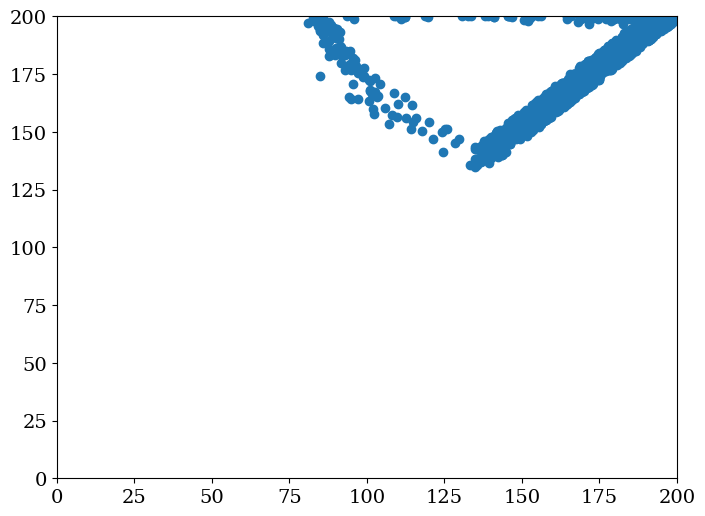

In [71]:
for i in range(len(pt_params)):
    P = pt_params[i]
    if P[:4] == pt_high_amp_params[0]:
        break

for j in range(len(cpt_params)):
    P = cpt_params[j]
    if P[:4] == pt_high_amp_params[0]:
        break

plt.scatter(
    pt_states[i][0],
    pt_states[i][1]
)
plt.xlim(0,200)
plt.ylim(0,200)
plt.show()
    

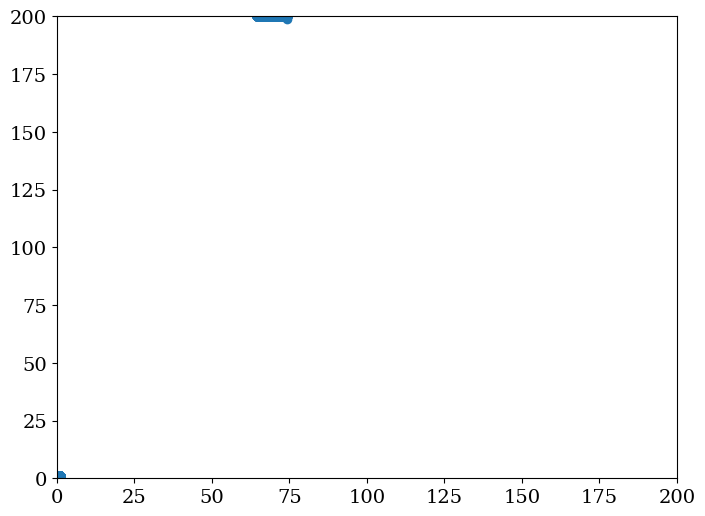

In [67]:
plt.scatter(
    cpt_states[j][0],
    cpt_states[j][1]
)
plt.xlim(0,200)
plt.ylim(0,200)
plt.show()

# Radar Plots for Param Values

In [ ]:
def load_data(directory):
    with open(f"../{directory}/dominant_frequencies_amplitudes.pickle", "rb") as f:
        freqs = pickle.load(f)
    y = np.array([np.mean(f["amplitudes"])for f in freqs])

    with open(f"../{directory}/params", "rb") as f:
        parameters = pickle.load(f)
    return np.array(parameters), y

# Load data
cpt_P, cpt_y = load_data("data/cpt/cpt_kt_95")
pt_P, pt_y = load_data("data/pt/pt_95")

# Analyzing Parameter Values vs. Amplitude

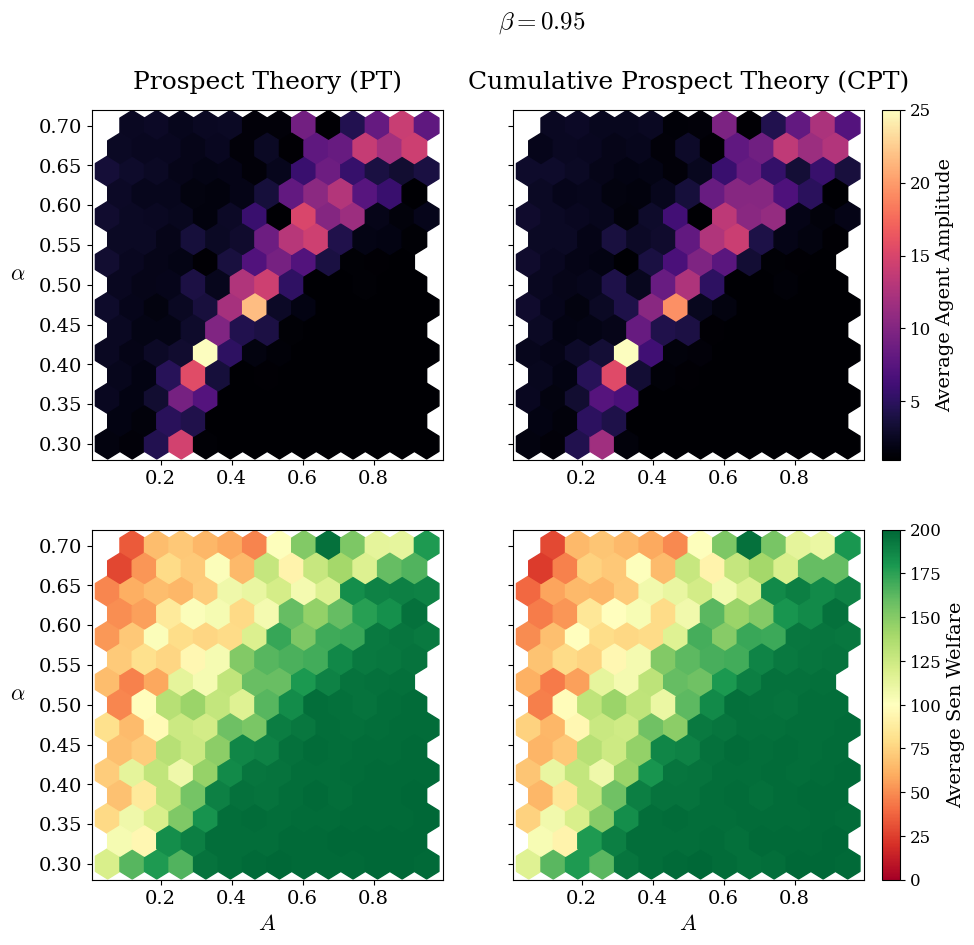

In [17]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import pickle

with open("../data/pt/pt_95/sen_welfare", 'rb') as f:
    pt_sen = pickle.load(f)
with open("../data/cpt/cpt_kt_95/sen_welfare", 'rb') as f:
    cpt_sen = pickle.load(f)

# --- Setup Figure ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

num_hex_bins = 13

# 1. Normalization for Amplitude (Top Row)
norm_top = mcolors.Normalize(vmin=1, vmax=25)

# 2. Normalization for Welfare (Bottom Row) - DIVERGING
# TwoSlopeNorm ensures the colormap is centered exactly at 100.
# Values < 100 go Red, > 100 go Green.
norm_bottom = mcolors.TwoSlopeNorm(vmin=0, vcenter=100, vmax=200)

param_names = [r"$\alpha$", r"$r$", r"$A$", r"$\lambda$", r"$\gamma$"]
x_name, y_name = r"$A$", r"$\alpha$"

# --- Data Prep ---
df_pt = pd.DataFrame(pt_P, columns=param_names)
df_pt = df_pt.loc[:, df_pt.std() > 0]

df_cpt = pd.DataFrame(cpt_P, columns=param_names)
df_cpt = df_cpt.loc[:, df_cpt.std() > 0]

# ==========================================
# ROW 1: Average Agent Amplitude (Magma)
# ==========================================

# 1. Plot Top-Left (PT)
hb_top = axs[0][0].hexbin(
    df_pt[x_name], df_pt[y_name], C=pt_y,
    gridsize=num_hex_bins, cmap='magma', reduce_C_function=np.mean,
    mincnt=1, norm=norm_top
)
axs[0][0].set_title("Prospect Theory (PT)", fontsize=18, pad=15)
axs[0][0].set_ylabel(y_name, fontsize=16, rotation=0, labelpad=15)

# 2. Plot Top-Right (CPT)
axs[0][1].hexbin(
    df_cpt[x_name], df_cpt[y_name], C=cpt_y,
    gridsize=num_hex_bins, cmap='magma', reduce_C_function=np.mean,
    mincnt=1, norm=norm_top
)
axs[0][1].set_title("Cumulative Prospect Theory (CPT)", fontsize=18, pad=15)

# 3. Create Shared Colorbar for Row 1
cb1 = fig.colorbar(hb_top, ax=axs[0, :], location='right', aspect=20, pad=0.02)
cb1.set_label("Average Agent Amplitude", fontsize=14)
cb1.ax.tick_params(labelsize=12)


# ==========================================
# ROW 2: Average Sen Welfare (Diverging)
# ==========================================

# 1. Plot Bottom-Left (PT)
hb_bottom = axs[1][0].hexbin(
    df_pt[x_name], df_pt[y_name], C=pt_sen,
    gridsize=num_hex_bins, cmap='RdYlGn', reduce_C_function=np.mean,
    mincnt=1, norm=norm_bottom
)
axs[1][0].set_xlabel(x_name, fontsize=16)
axs[1][0].set_ylabel(y_name, fontsize=16, rotation=0, labelpad=15)

# 2. Plot Bottom-Right (CPT)
axs[1][1].hexbin(
    df_cpt[x_name], df_cpt[y_name], C=cpt_sen,
    gridsize=num_hex_bins, cmap='RdYlGn', reduce_C_function=np.mean,
    mincnt=1, norm=norm_bottom
)
axs[1][1].set_xlabel(x_name, fontsize=16)

# 3. Create Shared Colorbar for Row 2
cb2 = fig.colorbar(hb_bottom, ax=axs[1, :], location='right', aspect=20, pad=0.02)
cb2.set_label("Average Sen Welfare", fontsize=14)
cb2.ax.tick_params(labelsize=12)

plt.suptitle(r"$\beta=0.95$")
#plt.savefig("../figures/phase_diagrams.pdf", bbox_inches="tight")
plt.show()

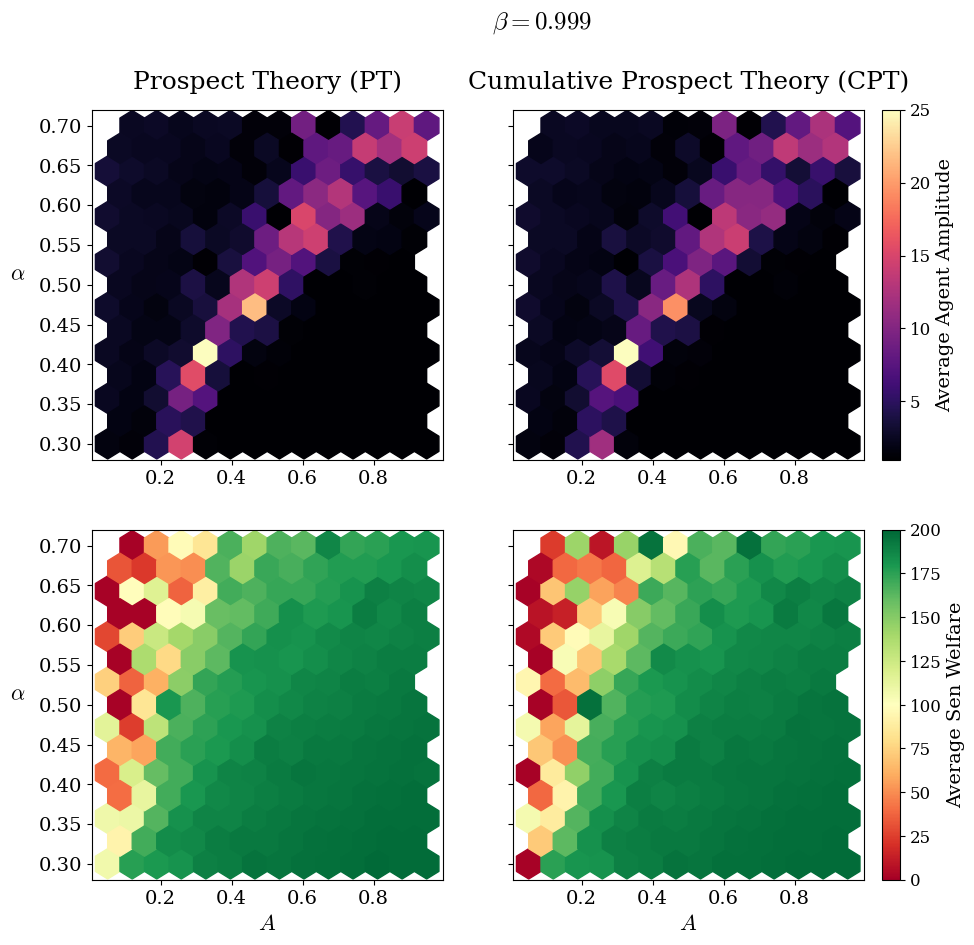

In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import pickle

with open("../data/pt/pt_999/sen_welfare", 'rb') as f:
    pt_sen = pickle.load(f)
with open("../data/cpt/cpt_kt_999/sen_welfare", 'rb') as f:
    cpt_sen = pickle.load(f)

# --- Setup Figure ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

num_hex_bins = 13

# 1. Normalization for Amplitude (Top Row)
norm_top = mcolors.Normalize(vmin=1, vmax=25)

# 2. Normalization for Welfare (Bottom Row) - DIVERGING
# TwoSlopeNorm ensures the colormap is centered exactly at 100.
# Values < 100 go Red, > 100 go Green.
norm_bottom = mcolors.TwoSlopeNorm(vmin=0, vcenter=100, vmax=200)

param_names = [r"$\alpha$", r"$r$", r"$A$", r"$\lambda$", r"$\gamma$"]
x_name, y_name = r"$A$", r"$\alpha$"

# --- Data Prep ---
df_pt = pd.DataFrame(pt_P, columns=param_names)
df_pt = df_pt.loc[:, df_pt.std() > 0]

df_cpt = pd.DataFrame(cpt_P, columns=param_names)
df_cpt = df_cpt.loc[:, df_cpt.std() > 0]

# ==========================================
# ROW 1: Average Agent Amplitude (Magma)
# ==========================================

# 1. Plot Top-Left (PT)
hb_top = axs[0][0].hexbin(
    df_pt[x_name], df_pt[y_name], C=pt_y,
    gridsize=num_hex_bins, cmap='magma', reduce_C_function=np.mean,
    mincnt=1, norm=norm_top
)
axs[0][0].set_title("Prospect Theory (PT)", fontsize=18, pad=15)
axs[0][0].set_ylabel(y_name, fontsize=16, rotation=0, labelpad=15)

# 2. Plot Top-Right (CPT)
axs[0][1].hexbin(
    df_cpt[x_name], df_cpt[y_name], C=cpt_y,
    gridsize=num_hex_bins, cmap='magma', reduce_C_function=np.mean,
    mincnt=1, norm=norm_top
)
axs[0][1].set_title("Cumulative Prospect Theory (CPT)", fontsize=18, pad=15)

# 3. Create Shared Colorbar for Row 1
cb1 = fig.colorbar(hb_top, ax=axs[0, :], location='right', aspect=20, pad=0.02)
cb1.set_label("Average Agent Amplitude", fontsize=14)
cb1.ax.tick_params(labelsize=12)


# ==========================================
# ROW 2: Average Sen Welfare (Diverging)
# ==========================================

# 1. Plot Bottom-Left (PT)
hb_bottom = axs[1][0].hexbin(
    df_pt[x_name], df_pt[y_name], C=pt_sen,
    gridsize=num_hex_bins, cmap='RdYlGn', reduce_C_function=np.mean,
    mincnt=1, norm=norm_bottom
)
axs[1][0].set_xlabel(x_name, fontsize=16)
axs[1][0].set_ylabel(y_name, fontsize=16, rotation=0, labelpad=15)

# 2. Plot Bottom-Right (CPT)
axs[1][1].hexbin(
    df_cpt[x_name], df_cpt[y_name], C=cpt_sen,
    gridsize=num_hex_bins, cmap='RdYlGn', reduce_C_function=np.mean,
    mincnt=1, norm=norm_bottom
)
axs[1][1].set_xlabel(x_name, fontsize=16)

# 3. Create Shared Colorbar for Row 2
cb2 = fig.colorbar(hb_bottom, ax=axs[1, :], location='right', aspect=20, pad=0.02)
cb2.set_label("Average Sen Welfare", fontsize=14)
cb2.ax.tick_params(labelsize=12)

plt.suptitle(r"$\beta=0.999$")
#plt.savefig("../figures/phase_diagrams.pdf", bbox_inches="tight")
plt.show()

# Visualize Limit Cycles

{'N': 200, 'alpha': np.float64(0.58), 'gamma': np.float64(0.8), 'lambda': np.float64(2.5), 'eta': 0.88, 'P_H_increase': 0.95, 'P_H_decrease': 0.05, 'rate': np.float64(3.64), 'A': np.float64(0.6), 'theta': 0.88, 'beta': 0.95}


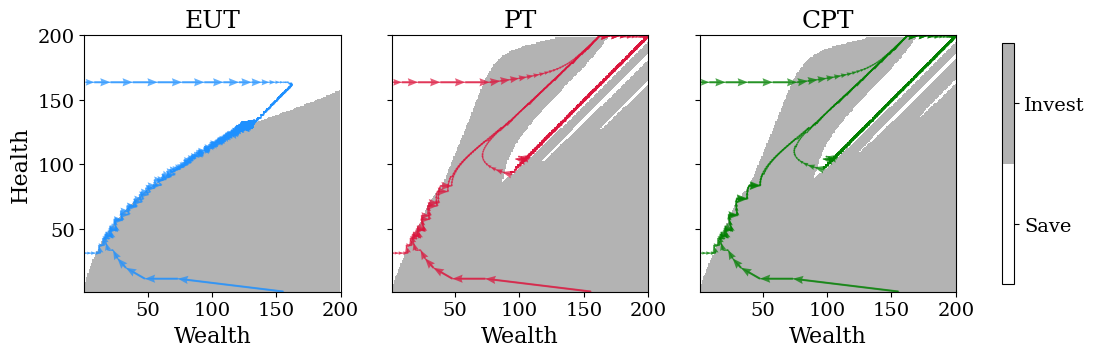

In [ ]:
def plot_trajectories(ax, res, color, indices):
    """
    Helper function to plot random agent trajectories with arrows.
    """
    for i in indices:
        w_path = unpack_and_dequantize(res["wealth"][i, :1800], 200)
        h_path = unpack_and_dequantize(res["health"][i, :1800], 200)
        ax.plot(w_path, h_path, color=color, alpha=0.5, linewidth=1)
        x = w_path[:-1]
        y = h_path[:-1]
        u = np.diff(w_path)
        v = np.diff(h_path)
        ax.quiver(x, y, u, v, color=color, alpha=0.7, 
                  angles='xy', scale_units='xy', scale=1, 
                  width=0.008, headwidth=4, headlength=5)


fig, axs = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

# Define a discrete binary colormap for consistency across plots
# This divides the 'Greys' map into exactly 2 colors
binary_cmap = plt.cm.get_cmap('Greys', 2)

# --- CPT ---
with open(os.path.join("../data/cpt/cpt_kt_95/raw/0.58_0.8_2.5_3.64_0.6.pickle"), "rb") as f:
    res = pickle.load(f)
P = res["params"]

w_start = res["wealth"][:,0]
h_start = res["health"][:,0]

# Determine midpoint based on data range (handles normalized 0-1 or integer 0-200)
# We assume the plot limits (200) represent the full scale.
data_max = np.max(w_start)
mid = 100 if data_max > 1 else 0.5

quadrants = [
    (w_start >= mid) & (h_start >= mid), # Q1
    (w_start < mid) & (h_start >= mid),  # Q2
    (w_start < mid) & (h_start < mid),   # Q3
    (w_start >= mid) & (h_start < mid)   # Q4
]
indices = []
for mask in quadrants:
    candidates = np.where(mask)[0]
    if len(candidates) >= 1:
        picked = np.random.choice(candidates, 1, replace=False)
    else:
        picked = candidates
    indices.extend(picked)
indices = np.array(indices)

w = unpack_and_dequantize(res["wealth"][:,-1], 200)
h = unpack_and_dequantize(res["health"][:,-1], 200)
axs[2].imshow(res["policy"].T, origin="lower", cmap=binary_cmap, alpha=0.3)
axs[2].set_xlim(1, 200)
axs[2].set_ylim(1, 200)
axs[2].set_title("CPT")
axs[2].set_xlabel("Wealth")
plot_trajectories(axs[2], res, "green", indices)
print(res["params"])


# --- PT ---
pt_f = f"{P['alpha']}_1.0_{P["lambda"]}_{P['rate']}_{P['A']}.pickle"
with open(os.path.join("../data/pt/pt_95/raw/", pt_f), "rb") as f:
    res = pickle.load(f)

axs[1].imshow(res["policy"].T, origin="lower", cmap=binary_cmap, alpha=0.3)
w = unpack_and_dequantize(res["wealth"][:,-1], 200)
h = unpack_and_dequantize(res["health"][:,-1], 200)
axs[1].set_xlim(1, 200)
axs[1].set_ylim(1, 200)
axs[1].set_title("PT")
axs[1].set_xlabel("Wealth")
plot_trajectories(axs[1], res, "crimson", indices)

# --- EUT ---
eut_f = f"{P['alpha']}_1.0_1.0_{P['rate']}_{P['A']}.pickle"
with open(os.path.join("../data/eut/eut_95/raw/", eut_f), "rb") as f:
    res = pickle.load(f)
    
# Capture the image object (im) to pass to colorbar
im = axs[0].imshow(res["policy"].T, origin="lower", cmap=binary_cmap, alpha=0.3, vmin=0, vmax=1)
w = unpack_and_dequantize(res["wealth"][:,-1], 200)
h = unpack_and_dequantize(res["health"][:,-1], 200)
axs[0].set_xlim(1, 200)
axs[0].set_ylim(1, 200)
axs[0].set_title("EUT")
axs[0].set_xlabel("Wealth")
axs[0].set_ylabel("Health")
plot_trajectories(axs[0], res, "dodgerblue", indices)

cbar = fig.colorbar(im, ax=axs, location='right', ticks=[0.25, 0.75], fraction=0.013)
cbar.ax.set_yticklabels(['Save', 'Invest'])
plt.savefig("../figures/policy_trajectories_cycle.pdf", bbox_inches="tight")
plt.show()